# Feature Descriptors

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature, exposure
import sys

def run_sift(image_path):
    """Loads an image, detects SIFT keypoints, and returns the visualization."""
    
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None, None

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 1. Create SIFT object
    sift = cv2.SIFT_create()
    
    # 2. Detect keypoints and compute descriptors
    # kp will be a list of KeyPoint objects
    # des will be a numpy array of shape (num_keypoints, 128)
    kp, des = sift.detectAndCompute(gray, None)
    
    # 3. Draw keypoints on the original (color) image
    # This draws circles with size and orientation of the keypoint
    img_sift = cv2.drawKeypoints(img, kp, None, 
                                flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    
    print(f"SIFT: Found {len(kp)} keypoints.")
    
    # Convert BGR (OpenCV) to RGB (Matplotlib) for correct color display
    img_sift_rgb = cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB)
    
    return img_sift_rgb, gray # Return grayscale for HOG

In [2]:
def run_hog(gray_image):
    """Computes the HOG descriptor and a visualization image."""
    
    # 1. Compute HOG features
    # 'fd' is the feature descriptor (a long 1D vector)
    # 'hog_image' is the visualization
    fd, hog_image = feature.hog(gray_image, 
                                orientations=9, 
                                pixels_per_cell=(8, 8),
                                cells_per_block=(2, 2), 
                                visualize=True)
    
    # 2. Rescale the HOG image for better visualization
    # The output of feature.hog is in the range [0, 1]
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 0.02))
    
    print(f"HOG: Descriptor shape: {fd.shape}")
    
    return hog_image_rescaled

SIFT: Found 174 keypoints.
HOG: Descriptor vector length: 25668


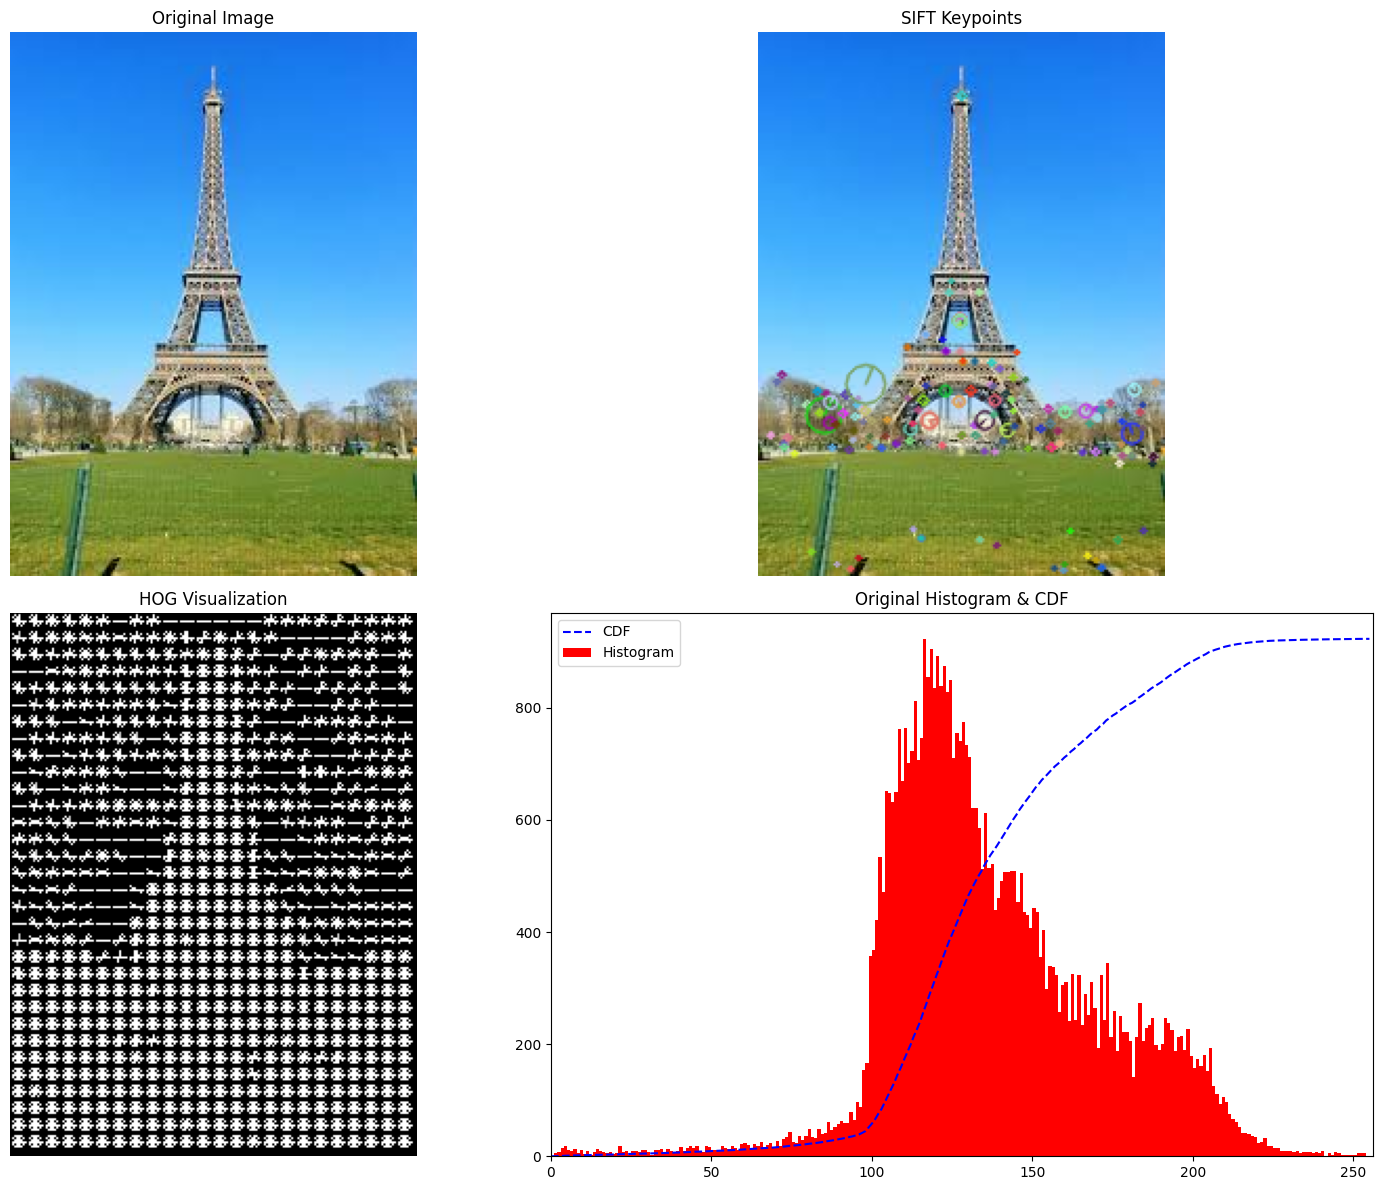

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature, exposure
import sys

def plot_histogram(img, title, ax):
    """Helper function to plot histogram and CDF."""
    # (Using the function from your previous prompt)
    if img is None:
        return
    if img.ndim > 2: # Check if it's a color image
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
    hist, bins = np.histogram(img.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    
    if cdf.max() > 0:
        cdf_normalized = cdf * hist.max() / cdf.max()
    else:
        cdf_normalized = cdf
        
    ax.set_title(title)
    ax.plot(cdf_normalized, color='b', linestyle='--')
    ax.hist(img.flatten(), 256, [0, 256], color='r')
    ax.legend(('CDF', 'Histogram'), loc='upper left')
    ax.set_xlim([0, 256])

def run_sift(img, gray):
    """Detects SIFT keypoints and returns the visualization."""
    sift = cv2.SIFT_create()
    kp, des = sift.detectAndCompute(gray, None)
    img_sift = cv2.drawKeypoints(img, kp, None, 
                                flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    print(f"SIFT: Found {len(kp)} keypoints.")
    img_sift_rgb = cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB)
    return img_sift_rgb

def run_hog(gray_image):
    """Computes the HOG descriptor and a visualization image."""
    fd, hog_image = feature.hog(gray_image, 
                                orientations=9, 
                                pixels_per_cell=(8, 8),
                                cells_per_block=(2, 2), 
                                visualize=True)
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 0.02))
    print(f"HOG: Descriptor vector length: {fd.shape[0]}")
    return hog_image_rescaled

# --- Main Execution ---

# 1. SET YOUR IMAGE PATH HERE
image_path = 'C:/Meet/PDEU/Semester 7/Computer Vision Lab/Computer-Vision/Images/Feature Descriptors/test_image1.jpeg' 

# 2. Load original image
img_original_bgr = cv2.imread(image_path)
if img_original_bgr is None:
    print(f"CRITICAL ERROR: Could not load image from {image_path}")
    sys.exit()

img_original_rgb = cv2.cvtColor(img_original_bgr, cv2.COLOR_BGR2RGB)
gray_original = cv2.cvtColor(img_original_bgr, cv2.COLOR_BGR2GRAY)

# 3. Run SIFT
img_sift = run_sift(img_original_bgr, gray_original)

# 4. Run HOG
img_hog = run_hog(gray_original)

# 5. Visualize Everything
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Original Image
axs[0, 0].imshow(img_original_rgb)
axs[0, 0].set_title('Original Image')
axs[0, 0].axis('off')

# SIFT Keypoints
axs[0, 1].imshow(img_sift)
axs[0, 1].set_title('SIFT Keypoints')
axs[0, 1].axis('off')

# HOG Visualization
axs[1, 0].imshow(img_hog, cmap='gray')
axs[1, 0].set_title('HOG Visualization')
axs[1, 0].axis('off')

# Original Histogram (from your previous code)
plot_histogram(gray_original, 'Original Histogram & CDF', axs[1, 1])

plt.tight_layout()
plt.show()